In [1]:
!pip install faster-whisper


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.9 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 MB 41.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.8/37.8 MB 39.2 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 76.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.1 MB/s eta 0:00:00


In [3]:
import os
import re
import pandas as pd
import numpy as np
import librosa
import soundfile as sf
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [4]:
# ============================================================================
# PHASE 1: AUDIO SEGMENTATION WITH SIMPLE VAD
# ============================================================================

class AudioSegmentationProcessor:
    def __init__(self, input_dir, output_dir, segment_duration=10.0, overlap=1.0):
        self.input_dir = Path(input_dir)
        self.output_dir = Path(output_dir)
        self.segment_duration = segment_duration
        self.overlap = overlap
        self.segments_data = []

        # VAD counters
        self.use_vad = True
        self.total_segments_created = 0
        self.segments_filtered = 0
        self.segments_with_speech = 0

        # Create directories
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self.segments_dir = self.output_dir / "segments"
        self.segments_dir.mkdir(parents=True, exist_ok=True)

    def segment_audio(self, audio_config):
        """Segment audio file with simple energy-based VAD"""
        audio_path = Path(audio_config['path'])
        show_name = audio_config['name']
        category = audio_config['category']

        try:
            # Load audio
            audio, sr = librosa.load(str(audio_path), sr=None)
            duration = len(audio) / sr

            # Segment setup
            segment_samples = int(self.segment_duration * sr)
            overlap_samples = int(self.overlap * sr)
            step_samples = segment_samples - overlap_samples

            segments_info = []
            segment_count = 0

            # Loop through audio
            for start_sample in range(0, len(audio) - segment_samples + 1, step_samples):
                end_sample = start_sample + segment_samples
                segment_audio = audio[start_sample:end_sample]

                start_time = start_sample / sr
                end_time = end_sample / sr
                actual_duration = len(segment_audio) / sr

                # Skip too-short segments
                if actual_duration < self.segment_duration * 0.5:
                    continue

                # Voice Activity Detection (simple energy check)
                if self.use_vad:
                    energy = np.mean(segment_audio**2)
                    if energy < 0.001:
                        self.segments_filtered += 1
                        continue
                    else:
                        self.segments_with_speech += 1

                self.total_segments_created += 1

                # Save segment
                segment_id = f"{audio_path.stem}_{segment_count:04d}"
                segment_filename = f"{segment_id}.wav"
                segment_path = self.segments_dir / segment_filename
                sf.write(str(segment_path), segment_audio, sr)

                segment_info = {
                    'FileName': f"{audio_path.parent.name}/{audio_path.name}",
                    'ShowName': show_name,
                    'FullFileLength': duration,
                    'SegmentID': segment_id,
                    'SegmentLength': actual_duration,
                    'SegmentStart': start_time,
                    'SegmentEnd': end_time,
                    'SpeakerAge': audio_config.get('SpeakerAge', 'Unknown'),
                    'SpeakerGender': audio_config.get('SpeakerGender', 'Unknown'),
                    'SpeakerDialect': audio_config.get('SpeakerDialect', 'Unknown'),
                    'Environment': audio_config.get('Environment', 'Unknown'),
                    'Speaker': f"Speaker_{segment_count % 5 + 1}",
                    'GroundTruthText': '',
                    'ProcessedText': '',
                    'Category': category,
                    'SegmentPath': str(segment_path)
                }

                segments_info.append(segment_info)
                segment_count += 1

            return segments_info

        except Exception as e:
            print(f" Error processing {audio_path}: {str(e)}")
            return []

    def process_all_files(self, audio_configs):
        """Process all audio files and return DataFrame"""
        print(f"Found {len(audio_configs)} audio files to process\n")

        all_segments = []
        for audio_config in tqdm(audio_configs, desc="Processing audio files"):
            audio_path = Path(audio_config['path'])
            print(f"\n🎧 Processing: {audio_path.name}")
            segments = self.segment_audio(audio_config)
            all_segments.extend(segments)
            print(f"✅ Created {len(segments)} valid segments")

        if all_segments:
            df = pd.DataFrame(all_segments)
            column_order = [
                'FileName', 'ShowName', 'FullFileLength', 'SegmentID', 'SegmentLength',
                'SegmentStart', 'SegmentEnd', 'SpeakerAge', 'SpeakerGender', 'SpeakerDialect',
                'Environment', 'Speaker', 'GroundTruthText', 'ProcessedText', 'Category', 'SegmentPath'
            ]
            df = df[column_order]
            print("\n PHASE 1 complete — segmented DataFrame:")
            print(df.head())
            return df
        else:
            print(" No segments were created.")
            return pd.DataFrame()

    def display_summary(self):
        """Display simple VAD statistics"""
        print(f"\n{'='*60}")
        print("VOICE ACTIVITY DETECTION (VAD) STATISTICS:")
        print(f"{'='*60}")
        total = self.total_segments_created + self.segments_filtered
        print(f"Total segments analyzed: {total}")
        print(f"✅ Segments with speech: {self.segments_with_speech} (saved)")
        print(f"❌ Silent segments filtered: {self.segments_filtered}")
        if total > 0:
            filter_rate = (self.segments_filtered / total) * 100
            print(f"Filter rate: {filter_rate:.1f}%")

In [5]:
# ============================================================================
#  PHASE 2: ARABIC TRANSCRIPTION USING FASTER-WHISPER
# ============================================================================

from faster_whisper import WhisperModel
import torch
import gc

def transcribe_with_faster_whisper(df, model_size="base"):
    """
    Transcribe Arabic speech using faster-whisper and add GroundTruthText column.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    compute_type = "float16" if device == "cuda" else "int8"

    print(f"\n Loading faster-whisper model ({model_size}) on {device} [{compute_type}] ...")
    model = WhisperModel(model_size, device=device, compute_type=compute_type)

    transcripts = []

    for i, row in tqdm(df.iterrows(), total=len(df), desc="Transcribing Arabic segments"):
        audio_path = row["SegmentPath"]
        try:
            # Transcribe with Arabic language fixed for faster inference
            segments, info = model.transcribe(audio_path, language="ar", beam_size=5)
            text = " ".join([seg.text.strip() for seg in segments])
        except Exception as e:
            text = f"Error: {e}"
        transcripts.append(text)

        # Clean up memory periodically
        if (i + 1) % 50 == 0:
            gc.collect()

    df["GroundTruthText"] = transcripts

    print("\n PHASE 2 complete — Arabic transcription sample:")
    print(df[["SegmentID", "GroundTruthText"]].head())
    return df


In [7]:
# ============================================================================
# PHASE 3 — Arabic Text Cleaning / Normalization
# ============================================================================
import re

def process_arabic_text(df):
    """
    Normalize Arabic transcription:
    - remove diacritics, tatweel
    - unify Alef/Ya forms
    - strip punctuation and extra spaces
    """
    arabic_norm = []
    arabic_diacritics = re.compile(r'[\u0617-\u061A\u064B-\u0652]')
    for text in df["GroundTruthText"].fillna(""):
        t = text
        # Remove diacritics and tatweel
        t = re.sub(arabic_diacritics, '', t)
        t = t.replace("ـ", "")
        # Normalize Alef/Ya forms
        t = re.sub(r"[إأآا]", "ا", t)
        t = re.sub(r"ى", "ي", t)
        t = re.sub(r"ؤ", "و", t)
        t = re.sub(r"ئ", "ي", t)
        # Remove punctuation / non-Arabic chars
        t = re.sub(r"[^ء-ي0-9\s]", " ", t)
        t = re.sub(r"\s+", " ", t).strip()
        arabic_norm.append(t)

    df["ProcessedText"] = arabic_norm

    print("\n PHASE 3 complete — normalized Arabic sample:")
    print(df[["SegmentID", "ProcessedText"]].head())
    return df




In [8]:
###########################################################################
# PHASE 4: SPEAKER METADATA & ENVIRONMENT DETECTION
###########################################################################
import os
import numpy as np
import pandas as pd
import librosa
from tqdm import tqdm
import torch


# ==========================================================
# Simple energy / pitch features (used when no model available)
# ==========================================================
def extract_basic_features(y, sr):
    """Extract simple spectral features to infer environment and rough pitch."""
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    spec_centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    rms = np.mean(librosa.feature.rms(y=y))
    return {"zcr": zcr, "spec_centroid": spec_centroid, "rms": rms}


# ==========================================================
# Environment classification
# ==========================================================
def detect_environment(y, sr):
    """Classify environment as clear / noisy / music."""
    feats = extract_basic_features(y, sr)
    if feats["spec_centroid"] > 3000 or feats["zcr"] > 0.1:
        return "Music"
    elif feats["rms"] > 0.04:
        return "Noisy"
    else:
        return "Clear"


# ==========================================================
# Gender & age prediction 
# ==========================================================
def predict_gender_and_age(y, sr):
    """Predict speaker gender and age using simple pitch-based heuristics."""
    try:
        f0 = librosa.yin(y, fmin=80, fmax=350)
        pitch = np.median(f0[np.isfinite(f0)])  # median pitch (Hz)
    except Exception:
        pitch = 0

    # Gender by pitch
    if pitch < 150:
        gender = "Male"
    elif pitch > 180:
        gender = "Female"
    else:
        gender = "Unknown"

    # Age heuristic by energy variation
    energy = np.mean(librosa.feature.rms(y=y))
    if energy < 0.02:
     age = "Elderly"
    elif 0.02 <= energy <= 0.07:
     age = "Adult"
    else:  # energy > 0.07
     age = "Child"

    return gender, age


# ==========================================================
# Process all segments
# ==========================================================
def process_segments_metadata(df_processed, segments_dir):
    """Add gender, age, and environment metadata directly to df_processed."""
    
    # Initialize new columns
    df_processed['SpeakerGender'] = None
    df_processed['SpeakerAge'] = None
    df_processed['Environment'] = None
    
    # Process each row in df_processed
    for idx, row in tqdm(df_processed.iterrows(), total=len(df_processed), desc="Analyzing segments"):
        try:
            # Get the segment file path from the DataFrame
            file_path = row['SegmentPath']  
            
            # Load audio and extract metadata
            y, sr = librosa.load(file_path, sr=None)
            gender, age = predict_gender_and_age(y, sr)
            env = detect_environment(y, sr)
            
            # Add metadata directly to the DataFrame
            df_processed.at[idx, 'SpeakerGender'] = gender
            df_processed.at[idx, 'SpeakerAge'] = age
            df_processed.at[idx, 'Environment'] = env
            
        except Exception as e:
            print(f"[WARN] Row {idx}, {file_path}: {e}")
    
    print("\n Metadata detection complete.")
    print(df_processed.head())
    
    return df_processed

   

In [9]:
# ============================================================================
# MAIN PIPELINE (PHASE 1 + PHASE 2 + PHASE 3 + phase 4)
# ============================================================================

def main():
    INPUT_DIR = "/kaggle/input/audio-files-16khz/audio_files_16kHz"
    OUTPUT_DIR = "/kaggle/working/segmented_south_north_16"

    audio_files = [
        {
            #1#
            'path': '/kaggle/input/audio-files-16khz/audio_files_16kHz/الثقافية أدب _ حس _ شعراء الجوف.wav',
            'name': 'الثقافية',
            'category': 'Program',
            'SpeakerDialect': 'North',            
        },
         {
             #2#
            'path': '/kaggle/input/audio-files-16khz/audio_files_16kHz/القهوة المخمرة ｜ تخمير القهوة ｜ بو ممدوح مونس العنزي.wav',
            'name': 'قناة البوادي',
            'category': 'Program',
            'SpeakerDialect': 'North',            
        },
    {
             #3#
            'path': '/kaggle/input/audio-files-16khz/audio_files_16kHz/زواج بالبر في تبوك： بين المعرس وراعي الهجن والشاعر ｜ فلان.wav',
            'name': 'ثمانية',
            'category': 'Documentary',
            'SpeakerDialect': 'North',            
        },
         {
             #4#
            'path': '/kaggle/input/audio-files-16khz/audio_files_16kHz/عطالله عاشق القهوة الشمالية.. يخمرها لنحو 5 سنوات.wav',
            'name': 'قناة القبس',
            'category': 'Program',
            'SpeakerDialect': 'North',            
        },
        {
             #5#
            'path': '/kaggle/input/audio-files-16khz/audio_files_16kHz/فلم وثائقي - شمال السعودية -الرولة.wav',
            'name': 'ABDULATEEF ASA',
            'category': 'Documentary',
            'SpeakerDialect': 'North',            
        },
        {
             #6#
            'path': '/kaggle/input/audio-files-16khz/audio_files_16kHz/فنجال الشمال.wav',
            'name': 'ثمانية',
            'category': 'Documentary',
            'SpeakerDialect': 'North',            
        },
         {
             #7#
            'path': '/kaggle/input/audio-files-16khz/audio_files_16kHz/قهوة أهل الشمال.wav',
            'name': 'قناة الثقافية',
            'category': 'Documentary',
            'SpeakerDialect': 'North',            
        },
        {
             #8#
            'path': '/kaggle/input/audio-files-16khz/audio_files_16kHz/كرم اهل الشمال.wav',
            'name': 'قناة الصحراء',
            'category': 'Program',
            'SpeakerDialect': 'North',            
        },
        {
             #9#
            'path': '/kaggle/input/audio-files-16khz/audio_files_16kHz/لقاء مونس العنزي في برنامج (ليالي الكويت) عن هواية اقتناء دلال القهوة.wav',
            'name': 'ليالي الكويت',
            'category': 'Program',
            'SpeakerDialect': 'North',            
        },
        {
             #10#
            'path': '/kaggle/input/audio-files-16khz/audio_files_16kHz/العساس مبارك سيف _ الشمال _ عرعر _ البحيرات _ مظله.wav',
            'name': 'قناة الصحراء',
            'category': 'Program',
            'SpeakerDialect': 'North',            
        } ,
     {
             #11#
            'path': '/kaggle/input/audio-files-16khz/audio_files_16kHz/مزهّب الطراقي_ الحفاوة والكرم في جفيفاء حائل _ فلان.wav',
            'name': 'ثمانية',
            'category': 'Documentary',
            'SpeakerDialect': 'North',            
        },
          {
            #12#
            'path': '/kaggle/input/audio-files-16khz/audio_files_16kHz/الحضن ｜ نجران برنامج وثائقي ( كنوز أمة ).wav',
            'name': 'كنوز أمة',
            'category': 'Program',
            'SpeakerDialect': 'South',            
        },
         {
             #13#
            'path': '/kaggle/input/audio-files-16khz/audio_files_16kHz/الزراعة في الحضن نجران (كنوز أمة ) برنامج وثائقي.wav',
            'name': 'كنوز أمة',
            'category': 'Program',
            'SpeakerDialect': 'South',            
        },
    {
             #14#
            'path': '/kaggle/input/audio-files-16khz/audio_files_16kHz/الزراعة وحياه اهل الجنوب قديما.wav',
            'name': 'alassmi600',
            'category': 'Vlog',
            'SpeakerDialect': 'South',            
        },
         {
             #15#
            'path': '/kaggle/input/audio-files-16khz/audio_files_16kHz/برنامج رحلة مع التراث نجران.wav',
            'name': 'برنامج رحلة مع التراث',
            'category': 'Program',
            'SpeakerDialect': 'South',            
        },
        {
             #16#
            'path': '/kaggle/input/audio-files-16khz/audio_files_16kHz/بيوت الطين في الحضن نجران.wav',
            'name': 'كنوز أمة',
            'category': 'Program',
            'SpeakerDialect': 'South',            
        },
        {
             #17#
            'path': '/kaggle/input/audio-files-16khz/audio_files_16kHz/حس _ نجران _ الثانية عشر.wav',
            'name': 'قناة الثقافية',
            'category': 'Documentary',
            'SpeakerDialect': 'South',            
        },
         {
             #18#
            'path': '/kaggle/input/audio-files-16khz/audio_files_16kHz/ذعبلوتن الجوهرة المخفية في أعماق الربع الخالي.wav',
            'name': 'قناة الاخبارية',
            'category': 'Documentary',
            'SpeakerDialect': 'South',            
        },
        {
             #19#
            'path': '/kaggle/input/audio-files-16khz/audio_files_16kHz/شرورة عروس الربع الخالي ـ فيلم وثائقي كنوز أمة.wav',
            'name': 'كنوز أمة',
            'category': 'Program',
            'SpeakerDialect': 'South',            
        },
        {
             #20#
            'path': '/kaggle/input/audio-files-16khz/audio_files_16kHz/عبدالرحمن الزهراني_ كدّاد وسواق تريلة _ فلان.wav',
            'name': 'ثمانية',
            'category': 'Documentary',
            'SpeakerDialect': 'South',            
        },
        {
             #21#
            'path': '/kaggle/input/audio-files-16khz/audio_files_16kHz/فرع الجبل ( كنوز أمة - برنامج وثائقي ) نجران محافظة بدر الجنوب نجران.wav',
            'name': 'كنوز أمة',
            'category': 'Documentary',
            'SpeakerDialect': 'South',            
        },
         {
             #22#
            'path': '/kaggle/input/audio-files-16khz/audio_files_16kHz/قصة مكان نجران.wav',
            'name': 'كنوز أمة',
            'category': 'Documentary',
            'SpeakerDialect': 'South',            
        },
        {
             #23#
            'path': '/kaggle/input/audio-files-16khz/audio_files_16kHz/كنوز أمة _ بدر الجنوب وجهة نجران السياحية - اكثر من 100سد.wav',
            'name': 'كنوز أمة',
            'category': 'Program',
            'SpeakerDialect': 'South',            
        },
        {
             #24#
            'path': '/kaggle/input/audio-files-16khz/audio_files_16kHz/وثائقي： البلاد.wav',
            'name': 'ثمانية',
            'category': 'Documentary',
            'SpeakerDialect': 'South',            
        },

    ]

    print("\n" + "="*70)
    print("PHASE 1: AUDIO SEGMENTATION")
    print("="*70)
    processor = AudioSegmentationProcessor(INPUT_DIR, OUTPUT_DIR, segment_duration=10.0, overlap=1.0)
    df_segments = processor.process_all_files(audio_files)
    processor.display_summary()

    if df_segments.empty:
        print(" No audio segments found — stopping pipeline.")
        return

    print("\n" + "="*70)
    print("PHASE 2: ARABIC TRANSCRIPTION (FASTER-WHISPER)")
    print("="*70)
    df_transcribed = transcribe_with_faster_whisper(df_segments, model_size="large")
    df_transcribed = df_transcribed[df_transcribed["GroundTruthText"].astype(str).str.strip() != ""].copy()
    df_processed = process_arabic_text(df_transcribed) 
   
    

    # *** PHASE 4 ***
    segments_dir = OUTPUT_DIR + "/segments"
    df_final = process_segments_metadata(df_processed, segments_dir)
    print("\n FINAL OUTPUT SAMPLE:")
    print(df_final.head())

    # Save after Phase 4
    output_csv = "/kaggle/working/segments_sn_large.csv"
    df_final.to_csv(output_csv, index=False, encoding='utf-8-sig')
    print(f"\n PIPELINE COMPLETE! Saved to: {output_csv}")
    print(f"   Total segments: {len(df_final)}")
    print(f"   Total columns: {len(df_final.columns)}")
    
    return df_final
    
if __name__ == "__main__":
    main()


PHASE 1: AUDIO SEGMENTATION
Found 24 audio files to process



Processing audio files:   0%|          | 0/24 [00:00<?, ?it/s]


🎧 Processing: الثقافية أدب _ حس _ شعراء الجوف.wav


Processing audio files:   4%|▍         | 1/24 [00:13<05:00, 13.08s/it]

✅ Created 51 valid segments

🎧 Processing: القهوة المخمرة ｜ تخمير القهوة ｜ بو ممدوح مونس العنزي.wav


...

config.json: 0.00B [00:00, ?B/s]

Transcribing Arabic segments: 100%|██████████| 2517/2517 [59:03<00:00,  1.41s/it]  



 PHASE 2 complete — Arabic transcription sample:
                              SegmentID  \
0  الثقافية أدب _ حس _ شعراء الجوف_0000   
1  الثقافية أدب _ حس _ شعراء الجوف_0001   
2  الثقافية أدب _ حس _ شعراء الجوف_0002   
3  الثقافية أدب _ حس _ شعراء الجوف_0003   
4  الثقافية أدب _ حس _ شعراء الجوف_0004   

                                     GroundTruthText  
0  حنا ثلاثة شباب مهتمين في الشعر أنا وفهد وسعيد ...  
1                                        منطقة الجوف  
2                                  اشتركوا في القناة  
3  اه الجو في منطقة شعب انا اذكر ابطي والله حافظه...  
4  خلينا نصب شاي أسلم يقول ماتت زوجته عنادة النما...  

 PHASE 3 complete — normalized Arabic sample:
                              SegmentID  \
0  الثقافية أدب _ حس _ شعراء الجوف_0000   
1  الثقافية أدب _ حس _ شعراء الجوف_0001   
2  الثقافية أدب _ حس _ شعراء الجوف_0002   
3  الثقافية أدب _ حس _ شعراء الجوف_0003   
4  الثقافية أدب _ حس _ شعراء الجوف_0004   

                                       ProcessedText  


Analyzing segments: 100%|██████████| 2517/2517 [01:30<00:00, 27.92it/s]



 Metadata detection complete.
                                            FileName  ShowName  \
0  audio_files_16kHz/الثقافية أدب _ حس _ شعراء ال...  الثقافية   
1  audio_files_16kHz/الثقافية أدب _ حس _ شعراء ال...  الثقافية   
2  audio_files_16kHz/الثقافية أدب _ حس _ شعراء ال...  الثقافية   
3  audio_files_16kHz/الثقافية أدب _ حس _ شعراء ال...  الثقافية   
4  audio_files_16kHz/الثقافية أدب _ حس _ شعراء ال...  الثقافية   

   FullFileLength                             SegmentID  SegmentLength  \
0      461.566312  الثقافية أدب _ حس _ شعراء الجوف_0000           10.0   
1      461.566312  الثقافية أدب _ حس _ شعراء الجوف_0001           10.0   
2      461.566312  الثقافية أدب _ حس _ شعراء الجوف_0002           10.0   
3      461.566312  الثقافية أدب _ حس _ شعراء الجوف_0003           10.0   
4      461.566312  الثقافية أدب _ حس _ شعراء الجوف_0004           10.0   

   SegmentStart  SegmentEnd SpeakerAge SpeakerGender SpeakerDialect  \
0           0.0        10.0      Child       Unknown    

In [10]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 33.7 MB/s eta 0:00:00a 0:00:01


In [20]:
###########################################################################
# PHASE 5: Evaluation
###########################################################################
"""
Dataset Quality Evaluation for Arabic Speech Recognition
Evaluates: Accuracy, WER, CER, Balance, Coverage, Quality Metrics
"""

import pandas as pd
import numpy as np
import io
from collections import Counter
import re
import jiwer
from tqdm import tqdm


# ============================================================================
# 1. WORD ERROR RATE (WER) & CHARACTER ERROR RATE (CER)
# ============================================================================
    
def evaluate_transcription_quality(df, reference_col="GroundTruthText", hypothesis_col="ProcessedText"):
    """
    Unified function that evaluates:
    - WER
    - CER
    - Translation quality (BLEU, ROUGE, METEOR if available)
    """

    print("\n" + "="*60)
    print(" OVERALL TRANSCRIPTION QUALITY EVALUATION")
    print("="*60)

    results = {}

    # ------------------------
    # 1. WER / CER
    # ------------------------
    wer_cer_results = evaluate_wer_cer_dataset(df, reference_col, hypothesis_col)
    results["wer_cer"] = wer_cer_results

    # ------------------------
    # 2. Translation quality metrics (optional)
    # ------------------------
    try:
        from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
        from rouge_score import rouge_scorer

        bleu_scores = []
        rouge_scores = []

        scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)

        for i, row in df.iterrows():
            ref = str(row[reference_col]).strip()
            hyp = str(row[hypothesis_col]).strip()

            if ref == "" or hyp == "" or ref in ["[ERROR]", "[SILENT]"]:
                continue

            # BLEU
            bleu = sentence_bleu(
                [ref.split()],
                hyp.split(),
                smoothing_function=SmoothingFunction().method1
            )
            bleu_scores.append(bleu)

            # ROUGE
            rouge = scorer.score(ref, hyp)
            rouge_scores.append(rouge)

        if bleu_scores:
            results["bleu"] = float(np.mean(bleu_scores))
        if rouge_scores:
            rouge1 = np.mean([r["rouge1"].fmeasure for r in rouge_scores])
            rougeL = np.mean([r["rougeL"].fmeasure for r in rouge_scores])
            results["rouge1"] = rouge1
            results["rougeL"] = rougeL

        print("\n Translation Quality Metrics:")
        print(f"   BLEU:   {results.get('bleu', 0):.4f}")
        print(f"   ROUGE-1 {results.get('rouge1', 0):.4f}")
        print(f"   ROUGE-L {results.get('rougeL', 0):.4f}")

    except Exception as e:
        print("\n Translation metrics skipped (NLTK/rouge not installed).")

    return results

# ============================================================================
# 2. CLASS BALANCE EVALUATION
# ============================================================================

def evaluate_class_balance(df):
    """Evaluate distribution balance for categorical features."""
    print("\n" + "="*60)
    print("  CLASS BALANCE EVALUATION")
    print("="*60)
    
    balance_report = {}
    
    # Gender Balance
    if 'SpeakerGender' in df.columns:
        gender_counts = df['SpeakerGender'].value_counts()
        total = len(df)
        
        print(f"\n Gender Distribution:")
        for gender, count in gender_counts.items():
            percentage = (count / total) * 100
            print(f"   {gender}: {count:,} ({percentage:.1f}%)")
        
        # Calculate imbalance ratio
        max_class = gender_counts.max()
        min_class = gender_counts.min()
        imbalance_ratio = max_class / min_class if min_class > 0 else float('inf')
        
        print(f"   Imbalance Ratio: {imbalance_ratio:.2f}:1")
        
        
        balance_report['gender'] = {
            'distribution': gender_counts.to_dict(),
            'imbalance_ratio': imbalance_ratio
        }
    
    # Age Balance
    if 'SpeakerAge' in df.columns:
        age_counts = df['SpeakerAge'].value_counts()
        total = len(df)
        
        print(f"\n Age Distribution:")
        for age, count in age_counts.items():
            percentage = (count / total) * 100
            print(f"   {age}: {count:,} ({percentage:.1f}%)")
        
        max_class = age_counts.max()
        min_class = age_counts.min()
        imbalance_ratio = max_class / min_class if min_class > 0 else float('inf')
        
        print(f"   Imbalance Ratio: {imbalance_ratio:.2f}:1")
        
        
        balance_report['age'] = {
            'distribution': age_counts.to_dict(),
            'imbalance_ratio': imbalance_ratio
        }
    
    # Environment Balance
    if 'Environment' in df.columns:
        env_counts = df['Environment'].value_counts()
        total = len(df)
        
        print(f"\n Environment Distribution:")
        for env, count in env_counts.items():
            percentage = (count / total) * 100
            print(f"   {env}: {count:,} ({percentage:.1f}%)")
        
        max_class = env_counts.max()
        min_class = env_counts.min()
        imbalance_ratio = max_class / min_class if min_class > 0 else float('inf')
        
        print(f"   Imbalance Ratio: {imbalance_ratio:.2f}:1")
        
        
        balance_report['environment'] = {
            'distribution': env_counts.to_dict(),
            'imbalance_ratio': imbalance_ratio
        }
    
    return balance_report

# ============================================================================
# 3. VOCABULARY & COVERAGE ANALYSIS
# ============================================================================

def analyze_vocabulary(df, sample_size=5000):
    """Analyze vocabulary richness and coverage."""
    print("\n" + "="*60)
    print(" VOCABULARY & COVERAGE ANALYSIS")
    print("="*60)
    
    if 'GroundTruthText' not in df.columns:
        print("  No GroundTruthText column found")
        return None
    
    # Sample data
    df_sample = df.sample(min(sample_size, len(df)), random_state=42)
    
    # Extract all words
    all_words = []
    all_chars = []
    
    for text in df_sample['GroundTruthText']:
        if pd.notna(text) and text not in ['[ERROR]', '[SILENT]']:
            # Arabic text processing
            text = str(text).strip()
            words = text.split()
            all_words.extend(words)
            all_chars.extend(list(text.replace(' ', '')))
    
    # Word statistics
    vocab_size = len(set(all_words))
    total_words = len(all_words)
    
    # Character statistics
    char_set = set(all_chars)
    total_chars = len(all_chars)
    
    # Word frequency
    word_freq = Counter(all_words)
    most_common = word_freq.most_common(20)
    
    print(f"\n Vocabulary Statistics:")
    print(f"   Unique words: {vocab_size:,}")
    print(f"   Total words: {total_words:,}")
    print(f"   Unique characters: {len(char_set)}")
    print(f"   Total characters: {total_chars:,}")
    print(f"   Vocabulary richness: {vocab_size/total_words:.4f}")
    
    print(f"\n Most Common Words:")
    for word, count in most_common[:10]:
        percentage = (count / total_words) * 100
        print(f"   {word}: {count:,} ({percentage:.2f}%)")
    
    # Check for Arabic characters
    arabic_chars = [c for c in char_set if '\u0600' <= c <= '\u06FF']
    print(f"\n Arabic Characters: {len(arabic_chars)}")
    
    return {
        'vocab_size': vocab_size,
        'total_words': total_words,
        'char_set_size': len(char_set),
        'vocab_richness': vocab_size/total_words,
        'most_common': most_common,
        'arabic_chars': len(arabic_chars)
    }

# ============================================================================
# 4. DATA QUALITY CHECKS
# ============================================================================

def check_data_quality(df):
    """Check for data quality issues."""
    print("\n" + "="*60)
    print(" DATA QUALITY CHECKS")
    print("="*60)
    
    quality_report = {}
    
    # Missing values
    print(f"\n Missing Values:")
    missing = df.isnull().sum()
    for col, count in missing.items():
        if count > 0:
            percentage = (count / len(df)) * 100
            print(f"   {col}: {count:,} ({percentage:.1f}%)")
    
    quality_report['missing_values'] = missing.to_dict()
    
    # Duplicate rows
    duplicates = df.duplicated().sum()
    print(f"\n Duplicate Rows: {duplicates:,} ({duplicates/len(df)*100:.1f}%)")
    quality_report['duplicates'] = duplicates
    
    # Check for audio file existence (if SegmentPath exists)
    if 'SegmentPath' in df.columns:
        import os
        missing_files = 0
        sample_paths = df['SegmentPath'].sample(min(100, len(df)), random_state=42)
        
        for path in sample_paths:
            if not os.path.exists(path):
                missing_files += 1
        
        print(f"\n Missing Audio Files (sample check): {missing_files}/100")
        quality_report['missing_files_rate'] = missing_files / 100
    
    # Check transcription quality
    if 'GroundTruthText' in df.columns:
        error_count = (df['GroundTruthText'] == '[ERROR]').sum()
        silent_count = (df['GroundTruthText'] == '[SILENT]').sum()
        empty_count = df['GroundTruthText'].isna().sum()
        
        print(f"\n Transcription Issues:")
        print(f"   Errors: {error_count:,} ({error_count/len(df)*100:.1f}%)")
        print(f"   Silent: {silent_count:,} ({silent_count/len(df)*100:.1f}%)")
        print(f"   Empty: {empty_count:,} ({empty_count/len(df)*100:.1f}%)")
        
        quality_report['transcription_errors'] = error_count
        quality_report['transcription_silent'] = silent_count
        quality_report['transcription_empty'] = empty_count
    
    return quality_report

# ============================================================================
# 5. OVERALL DATASET SCORE
# ============================================================================

def calculate_dataset_score(df, balance_report, quality_report, vocab_report):
    """Calculate overall dataset quality score (0-100)."""
    print("\n" + "="*60)
    print(" OVERALL DATASET QUALITY SCORE")
    print("="*60)
    
    scores = {}
    
    # 1. Balance Score (0-25 points)
    balance_score = 0
    if balance_report:
        for category, info in balance_report.items():
            ratio = info.get('imbalance_ratio', float('inf'))
            if ratio < 1.5:
                balance_score += 8.33
            elif ratio < 3:
                balance_score += 5
            else:
                balance_score += 2
    scores['balance'] = min(balance_score, 25)
    
    # 2. Completeness Score (0-25 points)
    completeness_score = 25
    if quality_report:
        missing_rate = sum(quality_report.get('missing_values', {}).values()) / (len(df) * len(df.columns))
        completeness_score -= missing_rate * 25
        
        dup_rate = quality_report.get('duplicates', 0) / len(df)
        completeness_score -= dup_rate * 10
    scores['completeness'] = max(completeness_score, 0)
    
    # 3. Vocabulary Richness (0-25 points)
    vocab_score = 0
    if vocab_report:
        richness = vocab_report.get('vocab_richness', 0)
        vocab_score = min(richness * 1000, 25)  # Scale to 0-25
    scores['vocabulary'] = vocab_score
    
    # 4. Transcription Quality (0-25 points)
    transcription_score = 25
    if quality_report:
        error_rate = quality_report.get('transcription_errors', 0) / len(df)
        silent_rate = quality_report.get('transcription_silent', 0) / len(df)
        
        transcription_score -= error_rate * 50
        transcription_score -= silent_rate * 25
    scores['transcription'] = max(transcription_score, 0)
    
    # Total score
    total_score = sum(scores.values())
    
    print(f"\n Component Scores:")
    print(f"   Balance: {scores['balance']:.1f}/25")
    print(f"   Completeness: {scores['completeness']:.1f}/25")
    print(f"   Vocabulary: {scores['vocabulary']:.1f}/25")
    print(f"   Transcription: {scores['transcription']:.1f}/25")
    
    print(f"\n TOTAL SCORE: {total_score:.1f}/100")
    
    if total_score >= 85:
        grade = "A - Excellent"
    elif total_score >= 70:
        grade = "B - Good"
    elif total_score >= 55:
        grade = "C - Fair"
    else:
        grade = "D - Needs Improvement"
    
    print(f" Grade: {grade}")
    
    return total_score, scores

# ============================================================================
# MAIN EVALUATION FUNCTION
# ============================================================================
def evaluate_dataset_complete(csv_path_or_zip, is_zip=True, 
                              reference_col='GroundTruthText', 
                              hypothesis_col='ProcessedText'):
    """Complete dataset evaluation from CSV or ZIP."""
    
    print("\n" + "="*70)
    print(" STARTING COMPREHENSIVE DATASET EVALUATION")
    print("="*70)
    
    # Load data
    if is_zip:
        print("\n Loading from ZIP file...")
        with zipfile.ZipFile(csv_path_or_zip, 'r') as zip_ref:
            csv_files = [f for f in zip_ref.namelist() if f.endswith('.csv')]
            if not csv_files:
                print("❌ No CSV file found in ZIP")
                return
            
            with zip_ref.open(csv_files[0]) as f:
                df = pd.read_csv(f, encoding='utf-8-sig')
    else:
        print("\n Loading CSV file...")
        df = pd.read_csv(csv_path_or_zip, encoding='utf-8-sig')
    
    print(f" Loaded {len(df):,} rows, {len(df.columns)} columns")
    print(f" Columns: {df.columns.tolist()}")
    
    # Run all evaluations
    print("\n" + "="*70)
    
    # *** 1. WER & CER (MOST IMPORTANT) ***
    wer_cer_results = evaluate_wer_cer_dataset(df, reference_col, hypothesis_col)
    
    # 2. Transcription Quality
    trans_results = evaluate_transcription_quality(df)
    
    # 3. Class Balance
    balance_report = evaluate_class_balance(df)
    
    # 4. Vocabulary Analysis
    vocab_report = analyze_vocabulary(df)
    
    # 5. Data Quality
    quality_report = check_data_quality(df)
    
    # 6. Overall Score
    total_score, scores = calculate_dataset_score(df, balance_report, quality_report, vocab_report)
    
    print("\n" + "="*70)
    print("✅ EVALUATION COMPLETE!")
    print("="*70)
    
    return {
        'dataframe': df,
        'wer_cer': wer_cer_results,  
        'transcription': trans_results,
        'balance': balance_report,
        'vocabulary': vocab_report,
        'quality': quality_report,
        'total_score': total_score,
        'component_scores': scores
    }

# ============================================================================
# USAGE EXAMPLES
# ============================================================================

if __name__ == "__main__":
  
     results = evaluate_dataset_complete(
         "/kaggle/working/segments_sn_large.csv", 
         is_zip=False
     )
    
    # Access results
    # df = results['dataframe']
    # score = results['total_score']
    # print(f"\nFinal Score: {score}")


 STARTING COMPREHENSIVE DATASET EVALUATION

 Loading CSV file...
 Loaded 2,517 rows, 16 columns
 Columns: ['FileName', 'ShowName', 'FullFileLength', 'SegmentID', 'SegmentLength', 'SegmentStart', 'SegmentEnd', 'SpeakerAge', 'SpeakerGender', 'SpeakerDialect', 'Environment', 'Speaker', 'GroundTruthText', 'ProcessedText', 'Category', 'SegmentPath']


 WER & CER EVALUATION
 Found reference column: 'GroundTruthText'
 Found hypothesis column: 'ProcessedText'


Calculating WER/CER: 100%|██████████| 2517/2517 [00:00<00:00, 7326.39it/s]



 WORD ERROR RATE (WER):
   Average: 14.79%
   Median:  9.52%
   Std Dev: 20.15%
   Min:     0.00%
   Max:     200.00%

 CHARACTER ERROR RATE (CER):
   Average: 2.88%
   Median:  1.94%
   Std Dev: 3.61%

 Quality Assessment:
   ✅✅ GOOD - Production-ready quality

 WER Distribution:
   Excellent (<10%):  50.1% of segments
   Good (10-20%):     21.8% of segments
   Fair (20-30%):     15.9% of segments
   Poor (>30%):       12.3% of segments

  Top 5 Worst Transcriptions:

   1. SegmentID: شرورة عروس الربع الخالي ـ فيلم وثائقي كنوز أمة_0172
      WER: 200.0% | CER: 20.0%
      Reference:  20-30...
      Hypothesis: 20 30...

   2. SegmentID: الثقافية أدب _ حس _ شعراء الجوف_0040
      WER: 100.0% | CER: 15.4%
      Reference:  موسيقى موسيقى...
      Hypothesis: موسيقي موسيقي...

   3. SegmentID: زواج بالبر في تبوك： بين المعرس وراعي الهجن والشاعر ｜ فلان_0033
      WER: 100.0% | CER: 16.7%
      Reference:  موسيقى...
      Hypothesis: موسيقي...

   4. SegmentID: زواج بالبر في تبوك： بين المعر

Calculating WER/CER: 100%|██████████| 2517/2517 [00:00<00:00, 7060.98it/s]



 WORD ERROR RATE (WER):
   Average: 14.79%
   Median:  9.52%
   Std Dev: 20.15%
   Min:     0.00%
   Max:     200.00%

 CHARACTER ERROR RATE (CER):
   Average: 2.88%
   Median:  1.94%
   Std Dev: 3.61%

 Quality Assessment:
   ✅✅ GOOD - Production-ready quality

 WER Distribution:
   Excellent (<10%):  50.1% of segments
   Good (10-20%):     21.8% of segments
   Fair (20-30%):     15.9% of segments
   Poor (>30%):       12.3% of segments

  Top 5 Worst Transcriptions:

   1. SegmentID: شرورة عروس الربع الخالي ـ فيلم وثائقي كنوز أمة_0172
      WER: 200.0% | CER: 20.0%
      Reference:  20-30...
      Hypothesis: 20 30...

   2. SegmentID: الثقافية أدب _ حس _ شعراء الجوف_0040
      WER: 100.0% | CER: 15.4%
      Reference:  موسيقى موسيقى...
      Hypothesis: موسيقي موسيقي...

   3. SegmentID: زواج بالبر في تبوك： بين المعرس وراعي الهجن والشاعر ｜ فلان_0033
      WER: 100.0% | CER: 16.7%
      Reference:  موسيقى...
      Hypothesis: موسيقي...

   4. SegmentID: زواج بالبر في تبوك： بين المعر

In [22]:
import zipfile
from pathlib import Path

working = Path("/kaggle/working/segmented_south_north_16/segments")
zip_path = working / "segmented_sn_16kHz.zip"

# Delete old zip
if zip_path.exists():
    zip_path.unlink()

# Create zip and add only *.wav files
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for wav_file in working.glob("*.wav"):
        zipf.write(wav_file, arcname=wav_file.name)

print("✅ Zipped only WAV files!")


✅ Zipped only WAV files!


In [ ]:
from shutil import copy

copy(zip_path, "/kaggle/working/segmented_sn_16kHz.zip")


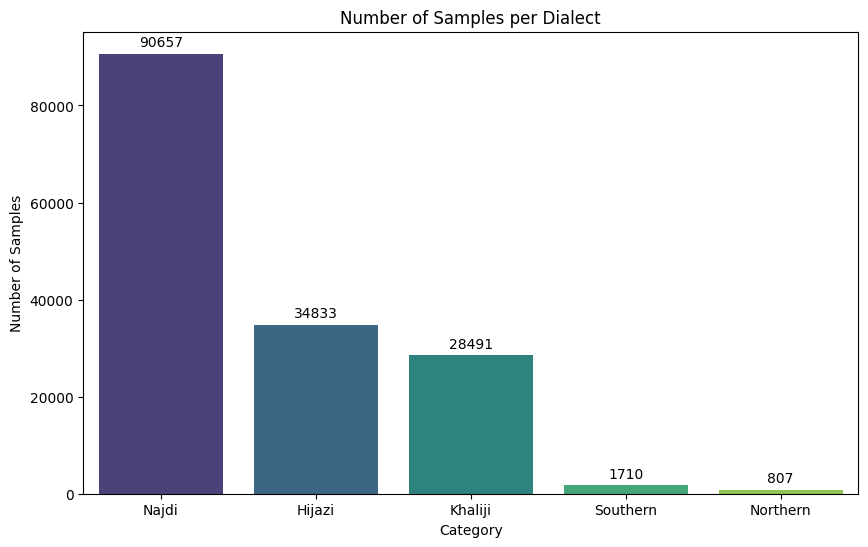

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSVs

dialects_df = pd.read_csv("/kaggle/input/sada-filtered/filtered_dialects.csv")  # Columns: e.g., 'dialect'
sn_df = pd.read_csv("/kaggle/working/segments_sn_small.csv")              # Columns: e.g., 'region'

# Count samples

dialect_counts = dialects_df['SpeakerDialect'].value_counts()
sn_counts = sn_df['SpeakerDialect'].value_counts()

# Combine into a single DataFrame for plotting

combined_df = pd.DataFrame({
'Najdi': [dialect_counts.get('Najdi', 0)],
'Hijazi': [dialect_counts.get('Hijazi', 0)],
'Khaliji': [dialect_counts.get('Khaliji', 0)],
'Southern': [sn_counts.get('South', 0)],
'Northern': [sn_counts.get('North', 0)]
}).T.reset_index()

combined_df.columns = ['Category', 'Count']

# Plot

plt.figure(figsize=(10,6))
ax = sns.barplot(data=combined_df, x='Category', y='Count', palette='viridis')
plt.title("Number of Samples per Dialect")
plt.ylabel("Number of Samples")
plt.xlabel("Category")
plt.xticks(rotation=0)

#Annotate each bar with the count

for p in ax.patches:
    height = p.get_height()
    ax.text(
    x=p.get_x() + p.get_width() / 2,
    y=height + max(combined_df['Count']) * 0.01, # Slightly above the bar
    s=f"{int(height)}",
    ha='center',
    va='bottom'
    )

plt.show()
